# 02 - Distance Metrics

---

In the previous notebook, we learned about Embeddings.

Now we have vectors.

But a new question appears:

How do we measure whether two vectors are similar?

This notebook introduces the most common distance metrics used in Machine Learning and Vector Databases.

##  History

Researchers converted text into vectors.

Great!

Now every document has become a point in space.

But computers still don't know which vectors are "close."

Researchers needed mathematical ways to measure similarity.

These became Distance Metrics.

## Think Like a Researcher

Imagine two cities.

City A

↓

Guwahati

City B

↓

Shillong

Question:

How do we know which city is closer?

We calculate the distance.

Exactly the same idea applies to vectors.

Instead of cities,

we measure the distance between embeddings.

In [1]:
import numpy as np

A = np.array([2,3])

B = np.array([5,7])

C = np.array([8,1])

print(A)
print(B)
print(C)

[2 3]
[5 7]
[8 1]


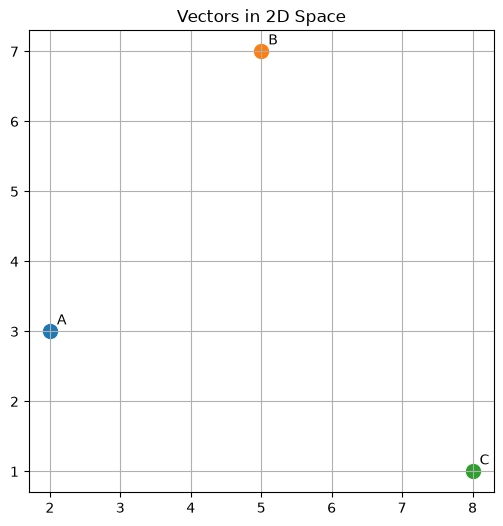

In [2]:
import matplotlib.pyplot as plt

points = {
    "A":A,
    "B":B,
    "C":C
}

plt.figure(figsize=(6,6))

for name,point in points.items():
    plt.scatter(point[0],point[1],s=100)
    plt.text(point[0]+0.1,point[1]+0.1,name)

plt.grid()

plt.title("Vectors in 2D Space")

plt.show()

## Observation

Each vector is simply a point.

Distance metrics tell us

how close

or

how far

these points are.

##  Euclidean Distance

Euclidean Distance is the straight-line distance between two points.

Imagine measuring the shortest path between two locations using a ruler.

It is one of the most common distance metrics.

In [3]:
euclidean = np.linalg.norm(A-B)

print(euclidean)

5.0


In [4]:
distance = np.sqrt(np.sum((A-B)**2))

print(distance)

5.0


## Manhattan Distance

Imagine you are driving in a city with square blocks.

You cannot move diagonally.

You move only:

Left

Right

Up

Down

This is Manhattan Distance.

In [5]:
manhattan = np.sum(np.abs(A-B))

print(manhattan)

7


## Dot Product

Dot Product measures how much two vectors point in the same direction.

Higher value

↓

More aligned.

It is commonly used inside Transformer attention.

In [6]:
dot = np.dot(A,B)

print(dot)

31


##  Cosine Similarity

Cosine Similarity measures

the angle

between vectors.

It ignores the length of the vectors.

Only direction matters.

This is why it is widely used for embeddings.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity([A],[B])

print(similarity)

[[0.99948011]]


In [8]:
v1 = np.array([1,1])

v2 = np.array([2,2])

v3 = np.array([-1,-1])

print(cosine_similarity([v1],[v2]))

print(cosine_similarity([v1],[v3]))

[[1.]]
[[-1.]]


## Observation

v1

and

v2

point in the same direction.

Cosine Similarity

≈ 1

v1

and

v3

point in opposite directions.

Cosine Similarity

≈ -1

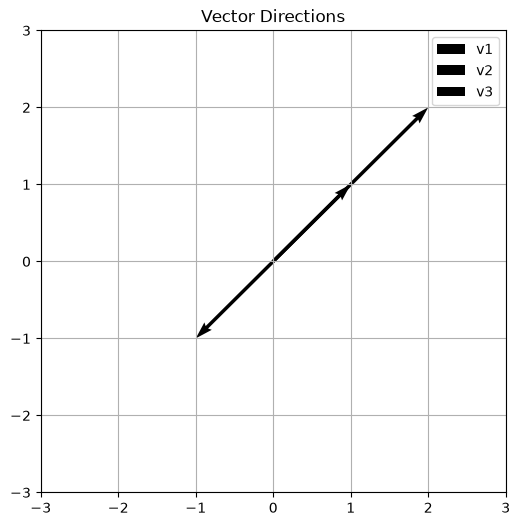

In [9]:
plt.figure(figsize=(6,6))

vectors = {
    "v1":v1,
    "v2":v2,
    "v3":v3
}

for name,vector in vectors.items():
    plt.quiver(
        0,
        0,
        vector[0],
        vector[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label=name
    )

plt.xlim(-3,3)
plt.ylim(-3,3)
plt.grid()
plt.legend()
plt.title("Vector Directions")
plt.show()

## Which Metric Should We Use?

Euclidean

✔ Measures straight-line distance

Good for numerical data.

---

Manhattan

✔ Grid-like movement

Useful in some optimization problems.

---

Dot Product

✔ Measures alignment.

Used in Transformers.

---

Cosine Similarity

✔ Measures semantic similarity.

Most common for text embeddings.

In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

texts = [
    "Artificial Intelligence",
    "Machine Learning",
    "Football"
]

embeddings = model.encode(texts)

cosine_similarity(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

array([[1.        , 0.70346254, 0.31145293],
       [0.70346254, 1.0000005 , 0.2290065 ],
       [0.31145293, 0.2290065 , 1.        ]], dtype=float32)

## Why Cosine Similarity?

Embedding vectors may have different magnitudes.

Cosine Similarity ignores magnitude.

It focuses on direction.

This makes it a better choice for comparing semantic meaning.

##  Applications

Cosine Similarity

- RAG
- Semantic Search
- Chatbots
- Recommendation Systems

Dot Product

- Transformer Attention

Euclidean Distance

- Clustering
- KNN

##  Limitation

Distance metrics tell us

how similar

two vectors are.

But suppose you have

10 million vectors.

Will you compare

one query

with

10 million vectors?

That would be too slow.

We need a search algorithm.

## Summary

Today I learned:

- Euclidean Distance
- Manhattan Distance
- Dot Product
- Cosine Similarity
- Why cosine similarity is popular in Vector Databases

## Think Like a Researcher

Great!

Now we know how to calculate similarity.

But another question appears.

Suppose you have

100 million vectors.

Should we compare

the query

with

every vector?

That would be extremely slow.

Researchers asked:

Can we efficiently find the **K nearest vectors**?

This idea became **K-Nearest Neighbors (KNN)**.